<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Resume_Screening(Decision_Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv"
df=pd.read_csv(path)
df.head(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [7]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [8]:
df.isnull().any().any()

np.True_

In [9]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [10]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_478/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [11]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [12]:
#print missing value
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [13]:
df.drop('number', axis=1, inplace=True, errors='ignore')
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [14]:
df.shape

(1000, 11)

In [15]:
before_rows=df.shape[0]
df = df.dropna()
after_rows = df.shape[0]
print("Before rows:",before_rows)
print("After rows:",after_rows)
print("The number of dropped rows are:",before_rows-after_rows)

Before rows: 1000
After rows: 1000
The number of dropped rows are: 0


In [16]:
df.shape

(1000, 11)

In [17]:
clean_data = df.copy()


In [18]:
clean_data.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [19]:
clean_data.drop('relative_humidity_9am', axis=1, inplace=True, errors='ignore')
clean_data.drop('relative_humidity_3pm', axis=1, inplace=True, errors='ignore')
clean_data.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [20]:
# Drop both 'Recruiter Decision' and 'AI Score (0-100)' from features
X = clean_data.drop(['Recruiter Decision', 'AI Score (0-100)'], axis=1)
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [21]:
Y = clean_data['Recruiter Decision']
print(Y)

0        Hire
1        Hire
2        Hire
3        Hire
4        Hire
        ...  
995    Reject
996    Reject
997      Hire
998      Hire
999      Hire
Name: Recruiter Decision, Length: 1000, dtype: object


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [23]:
X_train

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count
541,542,Angie Roberts,"Deep Learning, Python, Machine Learning",6,B.Tech,Google ML,Data Scientist,89840,2
440,441,Zoe King,"Deep Learning, Python, Machine Learning",9,MBA,Google ML,Data Scientist,105724,10
482,483,Jodi Franklin,"React, C++, Java",10,MBA,Deep Learning Specialization,Software Engineer,76012,1
422,423,Zachary Cohen,"NLP, TensorFlow, Pytorch, Python",8,B.Sc,Deep Learning Specialization,AI Researcher,108667,0
778,779,Matthew Smith,"Deep Learning, Machine Learning, Python",10,B.Tech,No Certification,Data Scientist,58090,4
...,...,...,...,...,...,...,...,...,...
106,107,David Richardson,"NLP, Python, TensorFlow",9,B.Tech,AWS Certified,AI Researcher,105695,0
270,271,Amy Poole,"Machine Learning, SQL, Python",0,PhD,Google ML,Data Scientist,43642,7
860,861,Karen Acosta,"Pytorch, Python",8,B.Tech,AWS Certified,AI Researcher,94680,10
435,436,Maria Manning,"Python, Deep Learning, SQL",7,M.Tech,Deep Learning Specialization,Data Scientist,104836,5


In [24]:
X_test

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count
521,522,Heather Booker,"NLP, Pytorch, TensorFlow",9,B.Sc,No Certification,AI Researcher,108379,10
737,738,Matthew Kent,"Cybersecurity, Ethical Hacking",6,MBA,AWS Certified,Cybersecurity Analyst,56096,8
740,741,Jacob Chang,"Pytorch, Python, TensorFlow",5,MBA,AWS Certified,AI Researcher,77117,6
660,661,Brenda Hall,"Java, SQL",8,M.Tech,Google ML,Software Engineer,50950,8
411,412,Kent Davis,"Cybersecurity, Networking",4,PhD,No Certification,Cybersecurity Analyst,87051,0
...,...,...,...,...,...,...,...,...,...
468,469,Renee West,"C++, Java, SQL",2,MBA,Google ML,Software Engineer,62255,7
935,936,Eddie May,"Machine Learning, SQL",2,MBA,Deep Learning Specialization,Data Scientist,90929,7
428,429,Anna Morrison,"Networking, Linux",5,M.Tech,Google ML,Cybersecurity Analyst,61038,9
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,103006,7


In [25]:
Y_train

,Recruiter Decision
541,Hire
440,Hire
482,Hire
422,Hire
778,Hire
...,...
106,Hire
270,Reject
860,Hire
435,Hire


In [26]:
Y_test

,Recruiter Decision
521,Hire
737,Hire
740,Hire
660,Hire
411,Reject
...,...
468,Hire
935,Hire
428,Hire
7,Hire


In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns for X_train and X_test
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - this is crucial if one-hot encoding results in different columns for train and test
# This can happen if a category is present in train but not in test, or vice versa
X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Ensure all columns are numeric before scaling
X_train_aligned = X_train_aligned.apply(pd.to_numeric, errors='coerce')
X_test_aligned = X_test_aligned.apply(pd.to_numeric, errors='coerce')

# Drop any columns that became all NaN due to 'coerce' (shouldn't happen with get_dummies but good practice)
X_train_aligned.dropna(axis=1, inplace=True)
X_test_aligned.dropna(axis=1, inplace=True)

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aligned)
X_test_scaled = scaler.transform(X_test_aligned)

# Convert back to DataFrame (optional, but good for inspection and consistent with previous X_train/X_test as DataFrames)
X_train = pd.DataFrame(X_train_scaled, columns=X_train_aligned.columns, index=X_train_aligned.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_aligned.columns, index=X_test_aligned.index)

In [28]:
recruiter_decision_classifier = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
recruiter_decision_classifier.fit(X_train, Y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.6, 0.9, 'x[1] <= -0.81\ngini = 0.292\nsamples = 700\nvalue = [576.0, 124.0]'),
 Text(0.3333333333333333, 0.7, 'x[3] <= 0.402\ngini = 0.489\nsamples = 179\nvalue = [76, 103]'),
 Text(0.4666666666666667, 0.8, 'True  '),
 Text(0.13333333333333333, 0.5, 'x[1] <= -1.133\ngini = 0.274\nsamples = 110\nvalue = [18, 92]'),
 Text(0.06666666666666667, 0.3, 'gini = 0.081\nsamples = 71\nvalue = [3, 68]'),
 Text(0.2, 0.3, 'x[3] <= -0.227\ngini = 0.473\nsamples = 39\nvalue = [15, 24]'),
 Text(0.13333333333333333, 0.1, 'gini = 0.328\nsamples = 29\nvalue = [6, 23]'),
 Text(0.26666666666666666, 0.1, 'gini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.5333333333333333, 0.5, 'x[1] <= -1.457\ngini = 0.268\nsamples = 69\nvalue = [58.0, 11.0]'),
 Text(0.4666666666666667, 0.3, 'x[3] <= 1.03\ngini = 0.493\nsamples = 25\nvalue = [14.0, 11.0]'),
 Text(0.4, 0.1, 'gini = 0.26\nsamples = 13\nvalue = [2, 11]'),
 Text(0.5333333333333333, 0.1, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.6, 0.3, 'gi

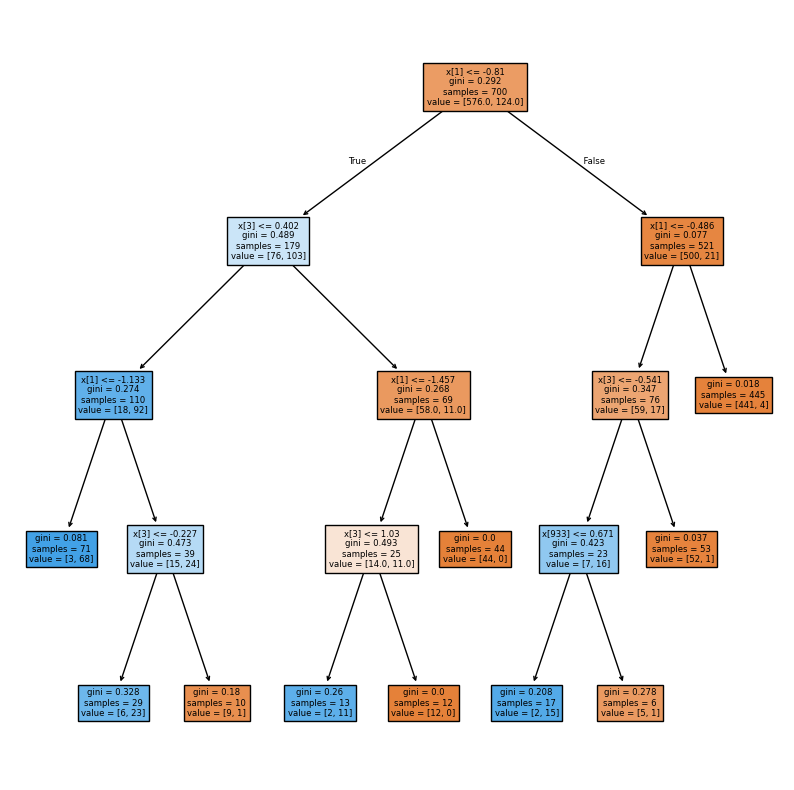

In [29]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(recruiter_decision_classifier, filled=True)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [31]:
X_train

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count
29,30,Steven Thomas,"SQL, Python",10,B.Tech,AWS Certified,Data Scientist,59926,4
535,536,Heather Watson,"React, SQL",4,PhD,No Certification,Software Engineer,108770,10
695,696,Marcus Garrett,"Cybersecurity, Linux, Ethical Hacking, Networking",3,MBA,Deep Learning Specialization,Cybersecurity Analyst,118062,8
557,558,Jessica Campbell,"Machine Learning, Deep Learning, Python",7,B.Tech,Deep Learning Specialization,Data Scientist,99741,0
836,837,Kelly Jones,"Deep Learning, Python",9,B.Tech,Google ML,Data Scientist,91723,8
...,...,...,...,...,...,...,...,...,...
106,107,David Richardson,"NLP, Python, TensorFlow",9,B.Tech,AWS Certified,AI Researcher,105695,0
270,271,Amy Poole,"Machine Learning, SQL, Python",0,PhD,Google ML,Data Scientist,43642,7
860,861,Karen Acosta,"Pytorch, Python",8,B.Tech,AWS Certified,AI Researcher,94680,10
435,436,Maria Manning,"Python, Deep Learning, SQL",7,M.Tech,Deep Learning Specialization,Data Scientist,104836,5


In [32]:
X_test

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count
521,522,Heather Booker,"NLP, Pytorch, TensorFlow",9,B.Sc,No Certification,AI Researcher,108379,10
737,738,Matthew Kent,"Cybersecurity, Ethical Hacking",6,MBA,AWS Certified,Cybersecurity Analyst,56096,8
740,741,Jacob Chang,"Pytorch, Python, TensorFlow",5,MBA,AWS Certified,AI Researcher,77117,6
660,661,Brenda Hall,"Java, SQL",8,M.Tech,Google ML,Software Engineer,50950,8
411,412,Kent Davis,"Cybersecurity, Networking",4,PhD,No Certification,Cybersecurity Analyst,87051,0
...,...,...,...,...,...,...,...,...,...
408,409,Timothy Fitzgerald,"Networking, Linux",3,MBA,No Certification,Cybersecurity Analyst,97811,6
332,333,Kimberly Thompson,"TensorFlow, Pytorch",5,PhD,AWS Certified,AI Researcher,79405,4
208,209,Derrick Mendoza,"Cybersecurity, Ethical Hacking, Networking, Linux",1,M.Tech,Deep Learning Specialization,Cybersecurity Analyst,102390,6
613,614,Caroline Ford,"Java, C++, SQL, React",7,B.Sc,Google ML,Software Engineer,115954,9


In [33]:
Y_train

,Recruiter Decision
29,Hire
535,Hire
695,Hire
557,Hire
836,Hire
...,...
106,Hire
270,Reject
860,Hire
435,Hire


In [34]:
Y_test

,Recruiter Decision
521,Hire
737,Hire
740,Hire
660,Hire
411,Reject
...,...
408,Hire
332,Hire
208,Hire
613,Hire


In [35]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns for X_train and X_test
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - this is crucial if one-hot encoding results in different columns for train and test
# This can happen if a category is present in train but not in test, or vice versa
X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Ensure all columns are numeric before scaling
X_train_aligned = X_train_aligned.apply(pd.to_numeric, errors='coerce')
X_test_aligned = X_test_aligned.apply(pd.to_numeric, errors='coerce')

# Drop any columns that became all NaN due to 'coerce' (shouldn't happen with get_dummies but good practice)
X_train_aligned.dropna(axis=1, inplace=True)
X_test_aligned.dropna(axis=1, inplace=True)

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aligned)
X_test_scaled = scaler.transform(X_test_aligned)

# Convert back to DataFrame (optional, but good for inspection and consistent with previous X_train/X_test as DataFrames)
X_train = pd.DataFrame(X_train_scaled, columns=X_train_aligned.columns, index=X_train_aligned.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_aligned.columns, index=X_test_aligned.index)

In [36]:
recruiter_decision_classifier = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
recruiter_decision_classifier.fit(X_train, Y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.6, 0.9, 'x[1] <= -0.782\ngini = 0.292\nsamples = 800\nvalue = [658, 142]'),
 Text(0.3333333333333333, 0.7, 'x[3] <= 0.395\ngini = 0.493\nsamples = 215\nvalue = [95, 120]'),
 Text(0.4666666666666667, 0.8, 'True  '),
 Text(0.13333333333333333, 0.5, 'x[1] <= -1.105\ngini = 0.253\nsamples = 128\nvalue = [19, 109]'),
 Text(0.06666666666666667, 0.3, 'gini = 0.07\nsamples = 83\nvalue = [3, 80]'),
 Text(0.2, 0.3, 'x[3] <= -0.231\ngini = 0.458\nsamples = 45\nvalue = [16.0, 29.0]'),
 Text(0.13333333333333333, 0.1, 'gini = 0.32\nsamples = 35\nvalue = [7, 28]'),
 Text(0.26666666666666666, 0.1, 'gini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.5333333333333333, 0.5, 'x[1] <= -1.428\ngini = 0.221\nsamples = 87\nvalue = [76.0, 11.0]'),
 Text(0.4666666666666667, 0.3, 'x[3] <= 1.02\ngini = 0.483\nsamples = 27\nvalue = [16, 11]'),
 Text(0.4, 0.1, 'gini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.5333333333333333, 0.1, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.6, 0.3, 'gini 

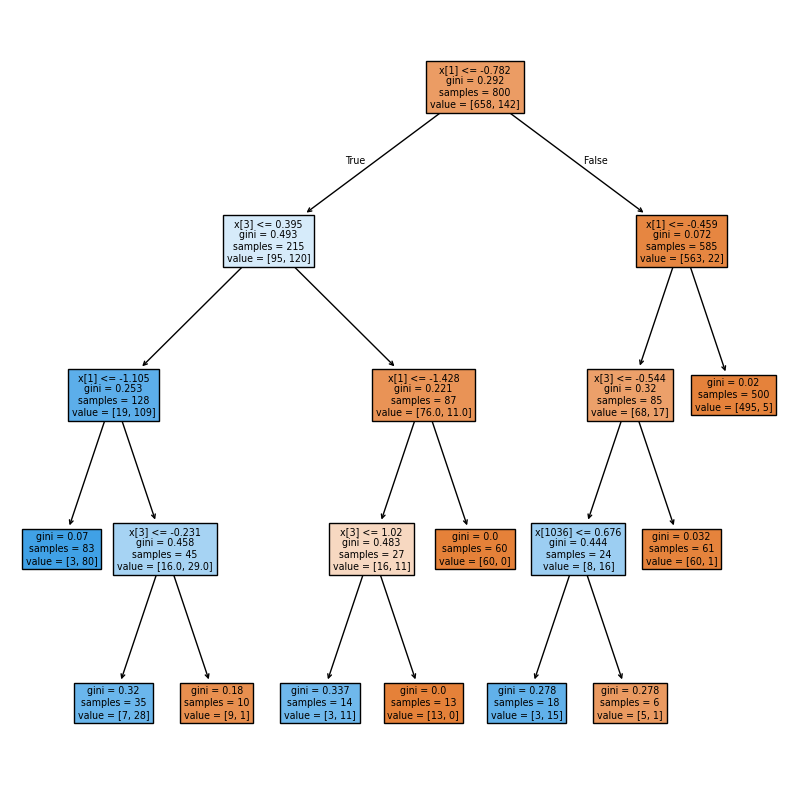

In [37]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(recruiter_decision_classifier, filled=True)

### Evaluation for `test_size=0.2`

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

Y_pred_0_2 = recruiter_decision_classifier.predict(X_test)

precision_0_2 = precision_score(Y_test, Y_pred_0_2, pos_label='Hire')
recall_0_2 = recall_score(Y_test, Y_pred_0_2, pos_label='Hire')
f1_0_2 = f1_score(Y_test, Y_pred_0_2, pos_label='Hire')

print(f"Precision for test_size=0.2: {precision_0_2:.2f}")
print(f"Recall for test_size=0.2: {recall_0_2:.2f}")
print(f"F1-Score for test_size=0.2: {f1_0_2:.2f}")

Precision for test_size=0.2: 0.97
Recall for test_size=0.2: 0.96
F1-Score for test_size=0.2: 0.97


In [40]:
from sklearn.metrics import accuracy_score

# Accuracy for test_size=0.2
accuracy_0_2 = accuracy_score(Y_test, Y_pred_0_2)
print(f"Accuracy for test_size=0.2: {accuracy_0_2:.2f}")

Accuracy for test_size=0.2: 0.95


Now, let's re-split the data with `test_size=0.3`, retrain the model, and evaluate its performance.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Re-split the data with test_size=0.3
X_train_0_3, X_test_0_3, Y_train_0_3, Y_test_0_3 = train_test_split(X, Y, test_size=0.3, random_state=42)

# Identify categorical columns
categorical_cols = X_train_0_3.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns for X_train and X_test
X_train_encoded_0_3 = pd.get_dummies(X_train_0_3, columns=categorical_cols, drop_first=True)
X_test_encoded_0_3 = pd.get_dummies(X_test_0_3, columns=categorical_cols, drop_first=True)

# Align columns
X_train_aligned_0_3, X_test_aligned_0_3 = X_train_encoded_0_3.align(X_test_encoded_0_3, join='left', axis=1, fill_value=0)

# Ensure all columns are numeric before scaling
X_train_aligned_0_3 = X_train_aligned_0_3.apply(pd.to_numeric, errors='coerce')
X_test_aligned_0_3 = X_test_aligned_0_3.apply(pd.to_numeric, errors='coerce')

# Drop any columns that became all NaN due to 'coerce'
X_train_aligned_0_3.dropna(axis=1, inplace=True)
X_test_aligned_0_3.dropna(axis=1, inplace=True)

# Initialize and apply StandardScaler
scaler_0_3 = StandardScaler()
X_train_scaled_0_3 = scaler_0_3.fit_transform(X_train_aligned_0_3)
X_test_scaled_0_3 = scaler_0_3.transform(X_test_aligned_0_3)

# Convert back to DataFrame
X_train_0_3 = pd.DataFrame(X_train_scaled_0_3, columns=X_train_aligned_0_3.columns, index=X_train_aligned_0_3.index)
X_test_0_3 = pd.DataFrame(X_test_scaled_0_3, columns=X_test_aligned_0_3.columns, index=X_test_aligned_0_3.index)

### Retraining the model for `test_size=0.3`

In [42]:
from sklearn.tree import DecisionTreeClassifier

recruiter_decision_classifier_0_3 = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
recruiter_decision_classifier_0_3.fit(X_train_0_3, Y_train_0_3)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

### Evaluation for `test_size=0.3`

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

Y_pred_0_3 = recruiter_decision_classifier_0_3.predict(X_test_0_3)

precision_0_3 = precision_score(Y_test_0_3, Y_pred_0_3, pos_label='Hire')
recall_0_3 = recall_score(Y_test_0_3, Y_pred_0_3, pos_label='Hire')
f1_0_3 = f1_score(Y_test_0_3, Y_pred_0_3, pos_label='Hire')

print(f"Precision for test_size=0.3: {precision_0_3:.2f}")
print(f"Recall for test_size=0.3: {recall_0_3:.2f}")
print(f"F1-Score for test_size=0.3: {f1_0_3:.2f}")

Precision for test_size=0.3: 0.98
Recall for test_size=0.3: 0.96
F1-Score for test_size=0.3: 0.97


In [44]:
from sklearn.metrics import accuracy_score

# Accuracy for test_size=0.3
accuracy_0_3 = accuracy_score(Y_test_0_3, Y_pred_0_3)
print(f"Accuracy for test_size=0.3: {accuracy_0_3:.2f}")

Accuracy for test_size=0.3: 0.95


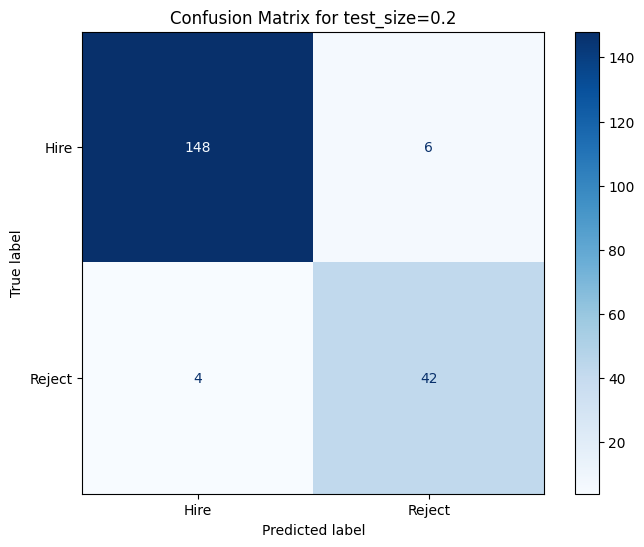

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for test_size=0.2
cm_0_2 = confusion_matrix(Y_test, Y_pred_0_2, labels=recruiter_decision_classifier.classes_)
disp_0_2 = ConfusionMatrixDisplay(confusion_matrix=cm_0_2, display_labels=recruiter_decision_classifier.classes_)

fig_0_2, ax_0_2 = plt.subplots(figsize=(8, 6))
disp_0_2.plot(ax=ax_0_2, cmap=plt.cm.Blues)
ax_0_2.set_title('Confusion Matrix for test_size=0.2')
plt.show()

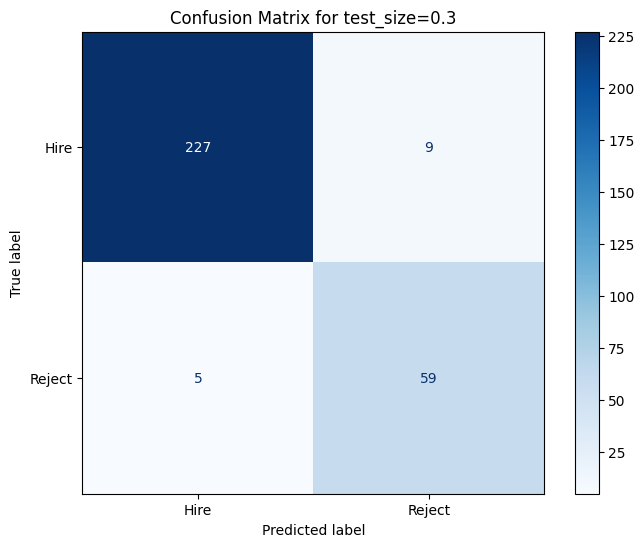

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for test_size=0.3
cm_0_3 = confusion_matrix(Y_test_0_3, Y_pred_0_3, labels=recruiter_decision_classifier_0_3.classes_)
disp_0_3 = ConfusionMatrixDisplay(confusion_matrix=cm_0_3, display_labels=recruiter_decision_classifier_0_3.classes_)

fig_0_3, ax_0_3 = plt.subplots(figsize=(8, 6))
disp_0_3.plot(ax=ax_0_3, cmap=plt.cm.Blues)
ax_0_3.set_title('Confusion Matrix for test_size=0.3')
plt.show()